# Parte 1 - Preparação do ambiente


In [2]:
import pandas as pd


In [3]:
df_qualidade_ar = pd.read_csv(
    "../datasets/qualidade_ar_brasil.csv", parse_dates=["data"]
)


# Parte 2 — Inspeção inicial do dataset


In [4]:
df_qualidade_ar.shape


(800, 11)

In [5]:
df_qualidade_ar.head()


,data,cidade,estado,pm25,pm10,no2,o3,temperatura,umidade,indice_qualidade_ar,nivel_alerta
0,2025-01-01,Brasília,DF,33.7,60.9,44.6,31.8,25.5,57.8,61.7,Moderado
1,2025-01-01,Curitiba,PR,25.7,22.1,29.4,40.0,17.1,77.4,43.4,Moderado
2,2025-01-01,Salvador,BA,18.8,27.6,29.2,60.2,29.3,78.0,47.5,Moderado
3,2025-01-02,Curitiba,PR,12.4,41.1,20.0,32.6,20.3,85.7,35.8,Bom
4,2025-01-03,Belo Horizonte,MG,32.0,57.3,36.4,23.5,26.3,74.6,54.1,Moderado


In [6]:
df_qualidade_ar.info()


<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 800 non-null    datetime64[us]
 1   cidade               800 non-null    str           
 2   estado               800 non-null    str           
 3   pm25                 800 non-null    float64       
 4   pm10                 800 non-null    float64       
 5   no2                  800 non-null    float64       
 6   o3                   800 non-null    float64       
 7   temperatura          800 non-null    float64       
 8   umidade              800 non-null    float64       
 9   indice_qualidade_ar  800 non-null    float64       
 10  nivel_alerta         800 non-null    str           
dtypes: datetime64[us](1), float64(7), str(3)
memory usage: 68.9 KB


In [7]:
df_qualidade_ar.describe().T


,count,mean,min,25%,50%,75%,max,std
data,800,2025-07-07 07:46:12,2025-01-01 00:00:00,2025-03-31 18:00:00,2025-07-11 12:00:00,2025-10-11 06:00:00,2025-12-31 00:00:00,NaN
pm25,800.0,26.597625,6.0,20.4,25.9,32.0,60.1,8.983311
pm10,800.0,46.8495,12.2,37.1,46.3,55.1,91.6,13.63357
no2,800.0,27.537125,5.0,21.7,26.8,32.9,61.7,9.157577
o3,800.0,32.405125,8.0,25.4,32.5,38.4,68.1,9.24701
temperatura,800.0,25.6405,14.5,22.3,25.85,29.1,36.1,4.608675
umidade,800.0,74.91875,47.3,69.275,76.25,81.425,96.0,9.492972
indice_qualidade_ar,800.0,47.758375,28.6,41.6,46.9,53.5,86.3,8.747129


In [8]:
df_qualidade_ar.describe(include="str").T


,count,unique,top,freq
cidade,800,10,Curitiba,93
estado,800,10,PR,93
nivel_alerta,800,3,Moderado,636


## Parte 2 Perguntas

1. Quantas medições existem no dataset? R:800
2. Quantas cidades estão presentes na base? R: 10
3. Quais colunas representam poluentes atmosféricos? (pm25,pm10,o3)
4. Existem valores ausentes no dataset? R: Nao


In [9]:
df_qualidade_ar.isna().sum()


data                   0
cidade                 0
estado                 0
pm25                   0
pm10                   0
no2                    0
o3                     0
temperatura            0
umidade                0
indice_qualidade_ar    0
nivel_alerta           0
dtype: int64

# Parte 3 — Análise por cidade


In [10]:
df_qualidade_ar.cidade.unique()


<StringArray>
[      'Brasília',       'Curitiba',       'Salvador', 'Belo Horizonte',
         'Recife',      'Fortaleza', 'Rio de Janeiro',   'Porto Alegre',
         'Manaus',      'São Paulo']
Length: 10, dtype: str

In [11]:
df_qualidade_ar.cidade.value_counts()


cidade
Curitiba          93
Brasília          87
Recife            85
Rio de Janeiro    83
Manaus            83
Fortaleza         80
Salvador          77
Belo Horizonte    77
Porto Alegre      71
São Paulo         64
Name: count, dtype: int64

In [12]:
df_qualidade_ar.groupby("cidade")[["pm25", "pm10", "no2", "o3"]].mean()


,pm25,pm10,no2,o3
cidade,,,,
Belo Horizonte,27.874026,48.409091,27.992208,30.141558
Brasília,31.351724,59.428736,29.926437,33.167816
Curitiba,25.339785,43.408602,26.151613,28.435484
Fortaleza,23.186250,44.662500,24.232500,34.176250
Manaus,26.271084,46.898795,22.566265,30.354217
Porto Alegre,26.798592,47.760563,27.959155,27.991549
Recife,23.416471,41.165882,24.320000,32.205882
Rio de Janeiro,27.825301,43.106024,30.925301,38.836145
Salvador,21.503896,39.102597,24.568831,34.274026


In [13]:
pd.crosstab(index=df_qualidade_ar["nivel_alerta"], columns=df_qualidade_ar["cidade"])


cidade,Belo Horizonte,Brasília,Curitiba,Fortaleza,Manaus,Porto Alegre,Recife,Rio de Janeiro,Salvador,São Paulo
nivel_alerta,,,,,,,,,,
Bom,15,2,24,24,20,10,24,5,26,0
Moderado,61,83,69,56,62,61,61,76,51,56
Ruim,1,2,0,0,1,0,0,2,0,8


## Perguntas

1. Qual cidade apresenta maior média de PM2.5? R: Sao Paulo
2. Qual cidade apresenta maior média de NO2? R: Sao Paulo
3. Existe alguma cidade com níveis consistentemente mais altos de poluentes? R: Brasilia


# Parte 4 — Análise do índice de qualidade do ar


In [14]:
df_qualidade_ar.groupby("cidade")["indice_qualidade_ar"].mean().sort_values(
    ascending=False
)


cidade
São Paulo         59.345312
Brasília          54.955172
Rio de Janeiro    50.639759
Belo Horizonte    48.344156
Porto Alegre      46.898592
Manaus            45.092771
Fortaleza         44.646250
Curitiba          44.359140
Recife            43.198824
Salvador          42.342857
Name: indice_qualidade_ar, dtype: float64

## Perguntas

1. Qual cidade apresenta pior qualidade média do ar? R: Salvador

2. Qual cidade apresenta melhor qualidade do ar? R: Sao Paulo


# Parte 5 — Filtragem por nível de alerta


In [15]:
df_alerta = df_qualidade_ar[
    df_qualidade_ar["nivel_alerta"].isin(["Ruim", "Muito Ruim"])
]
df_alerta.head()


,data,cidade,estado,pm25,pm10,no2,o3,temperatura,umidade,indice_qualidade_ar,nivel_alerta
235,2025-04-20,São Paulo,SP,33.7,73.7,57.2,34.3,25.9,61.1,70.8,Ruim
319,2025-06-01,Rio de Janeiro,RJ,45.1,70.1,37.4,48.0,28.1,78.9,72.7,Ruim
320,2025-06-02,Manaus,AM,53.6,79.5,25.2,36.2,31.7,74.9,71.6,Ruim
347,2025-06-17,Brasília,DF,52.7,79.1,35.4,31.9,28.6,51.0,73.5,Ruim
358,2025-06-20,Belo Horizonte,MG,44.5,78.9,41.8,46.1,27.0,64.8,75.9,Ruim


In [16]:
df_alerta.shape


(14, 11)

In [17]:
df_alerta.cidade.value_counts(ascending=False)


cidade
São Paulo         8
Rio de Janeiro    2
Brasília          2
Manaus            1
Belo Horizonte    1
Name: count, dtype: int64

<Axes: ylabel='cidade'>

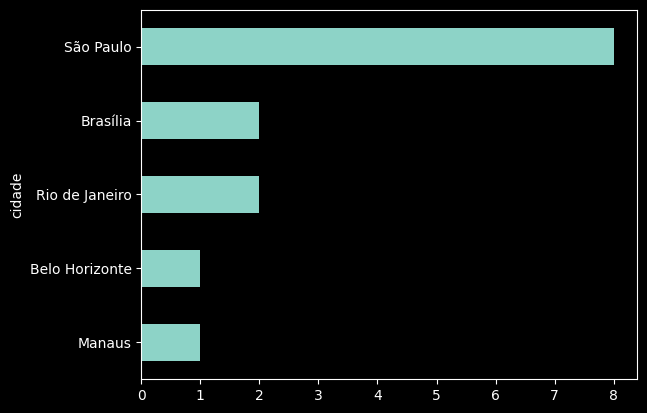

In [18]:
df_alerta.cidade.value_counts(ascending=True).plot.barh()


## Perguntas

1. Quantos registros possuem alerta crítico? R: 14
2. Em quais cidades eles ocorrem com maior frequência? R:Sao Paulo


# Parte 6 — Ranking dos dias mais críticos


In [19]:
df_qualidade_ar.sort_values("indice_qualidade_ar", ascending=False).head(10)


,data,cidade,estado,pm25,pm10,no2,o3,temperatura,umidade,indice_qualidade_ar,nivel_alerta
488,2025-08-19,São Paulo,SP,55.2,78.8,55.0,45.3,20.3,80.3,86.3,Ruim
431,2025-07-27,São Paulo,SP,60.1,50.0,56.4,54.8,25.2,76.3,84.3,Ruim
410,2025-07-15,São Paulo,SP,42.4,87.6,44.6,40.2,21.2,74.7,76.5,Ruim
379,2025-07-03,São Paulo,SP,51.7,78.9,48.3,26.8,21.6,68.0,76.1,Ruim
358,2025-06-20,Belo Horizonte,MG,44.5,78.9,41.8,46.1,27.0,64.8,75.9,Ruim
548,2025-09-17,Brasília,DF,54.3,69.2,37.4,36.0,23.8,62.5,73.6,Ruim
347,2025-06-17,Brasília,DF,52.7,79.1,35.4,31.9,28.6,51.0,73.5,Ruim
319,2025-06-01,Rio de Janeiro,RJ,45.1,70.1,37.4,48.0,28.1,78.9,72.7,Ruim
411,2025-07-15,São Paulo,SP,35.8,91.6,41.6,36.7,22.4,79.9,71.8,Ruim
320,2025-06-02,Manaus,AM,53.6,79.5,25.2,36.2,31.7,74.9,71.6,Ruim


## Perguntas

1. Qual foi o pior dia registrado? R: 19/08/2025
2. Em qual cidade ocorreu? R: Sao Paulo
3. Quais poluentes estavam mais altos nesse dia? R:pm10


# Parte 7 — Análise temporal


In [20]:
# Criando a coluna mês

df_qualidade_ar["mes"] = df_qualidade_ar["data"].dt.month_name()


In [ ]:
df_qualidade_ar.groupby("mes")["indice_qualidade_ar"].mean()


mes
April        47.559259
August       49.640000
December     45.829333
February     42.985714
January      44.852308
July         51.293443
June         52.881034
March        46.675949
May          47.107813
November     46.861429
October      47.865385
September    49.923333
Name: indice_qualidade_ar, dtype: float64

## Perguntas

1. Em quais meses a qualidade do ar tende a ser pior? R:Junho e Julho (Inverno)

2. Existe algum padrão sazonal? (Inverno)


# Parte 8 — Correlação entre variáveis


<Axes: >

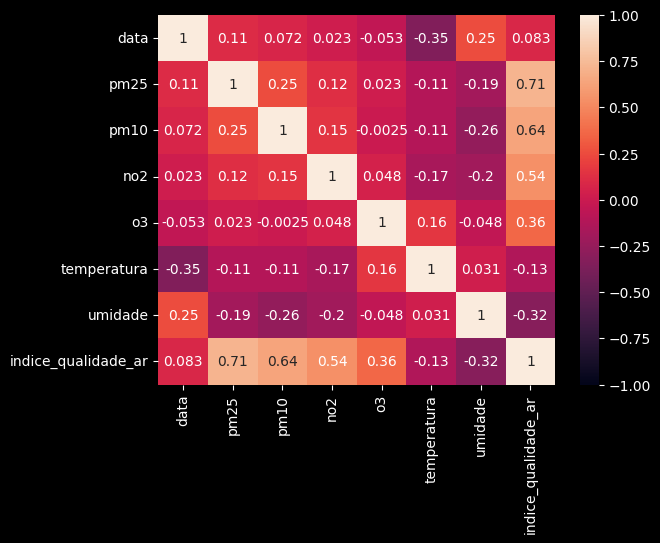

In [ ]:
import seaborn as sns

sns.heatmap(
    df_qualidade_ar.select_dtypes(exclude="str").corr(), annot=True, vmin=-1, vmax=1
)


<Axes: >

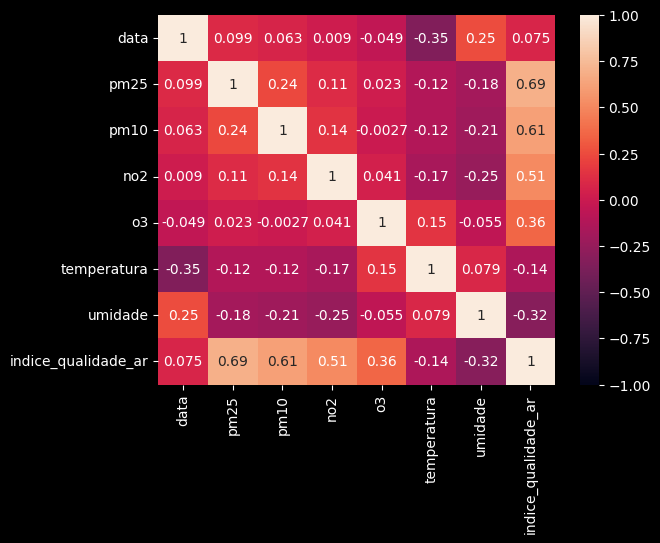

In [ ]:
sns.heatmap(
    df_qualidade_ar.select_dtypes(exclude="str").corr(method="spearman"),
    annot=True,
    vmin=-1,
    vmax=1,
)


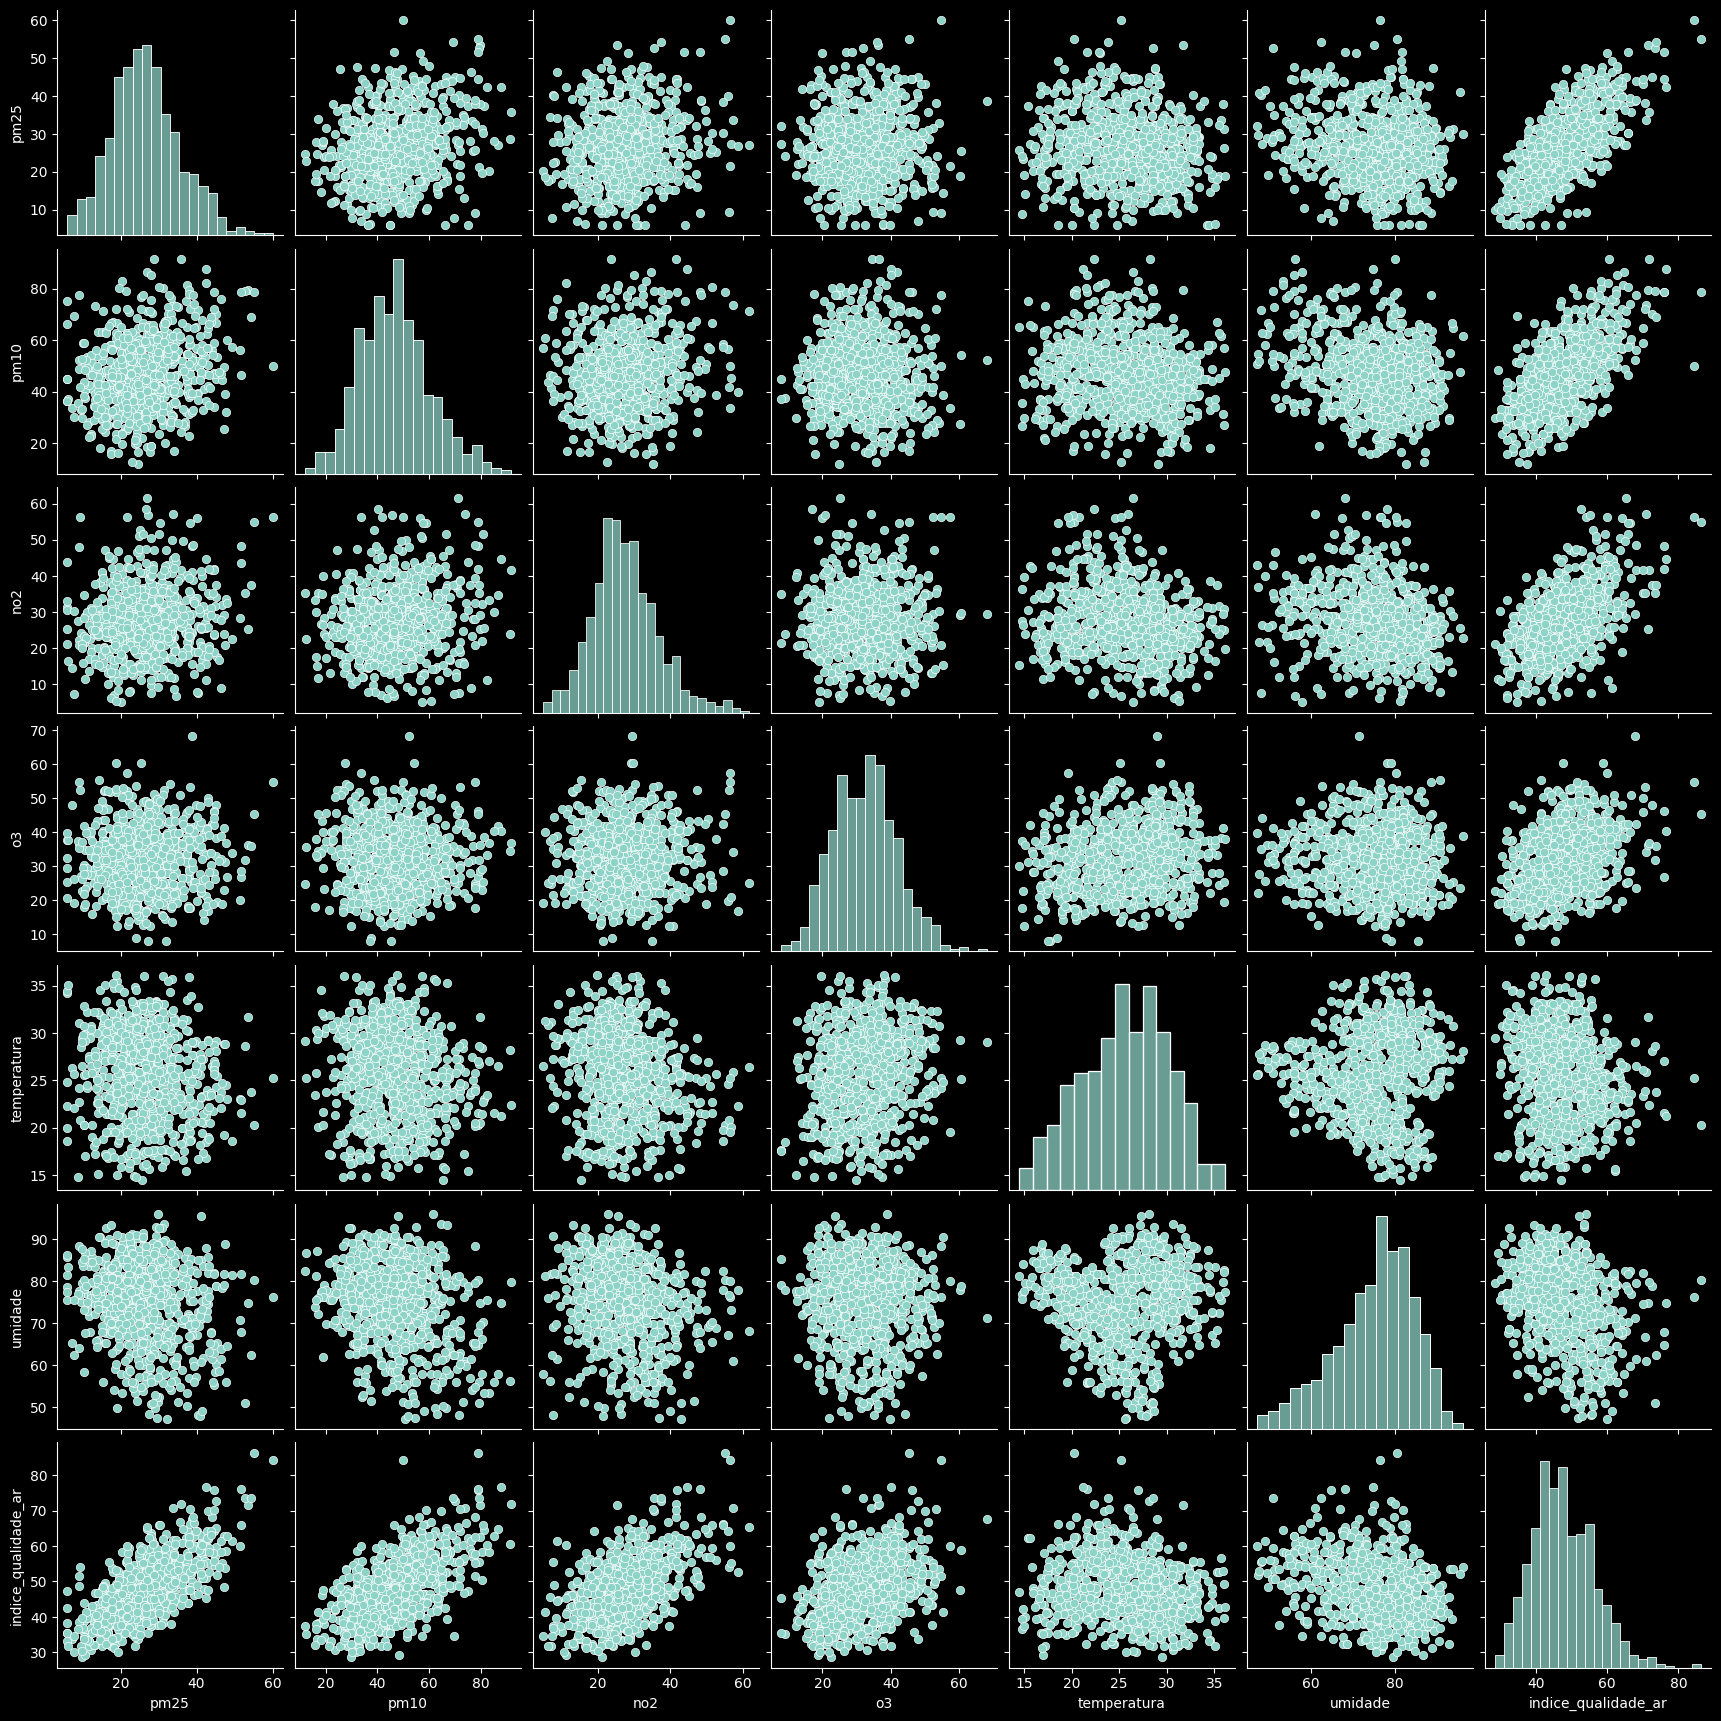

In [ ]:
sns.pairplot(df_qualidade_ar.select_dtypes(exclude="str"))


Podemos perceber que a pm25 é o que mais influencia a qualidade do ar junto do pm10, no2 e o3


## Perguntas

1. Existe correlação entre temperatura e poluição? R: Sim.
2. Quais poluentes parecem mais relacionados entre si? R: Há correlação relevante apenas entre os poluentes e o indice de qualidade do ar


# Desafio Final — Relatório para o Ministério


In [ ]:
df_qualidade_ar.groupby("cidade")["indice_qualidade_ar"].mean().sort_values(
    ascending=True
)


cidade
Salvador          42.342857
Recife            43.198824
Curitiba          44.359140
Fortaleza         44.646250
Manaus            45.092771
Porto Alegre      46.898592
Belo Horizonte    48.344156
Rio de Janeiro    50.639759
Brasília          54.955172
São Paulo         59.345312
Name: indice_qualidade_ar, dtype: float64

## Elabore um pequeno relatório respondendo:

1. Qual cidade apresenta pior qualidade média do ar? R: Salvador
2. Quais poluentes são mais críticos? R: pm25,pm10, no2
3. Existem meses mais problemáticos? R: Periodo de Inverno
4. Quais cidades deveriam receber maior atenção das autoridades ambientais? R: São Paulo


Conclusão: Tem algo errado com essa base de dados, De acordo com essa base de dados Salvador ta classificada como pior qualidade de ar, porém ela é a cidade que menos tem concentração de poluentes, e não contem nenhuma ocorrencia de nivel de alerta ruim. As maiores concentraçoes de nivel de alerta moderado para ruim são na cidade de Brasilia. O que também não fecha a conta.
Resumindo esse dataset está uma confusão!
